# Analysis of centrality (in progress)  

#### Done
1. Betweenness centrality data stored in raw/betw.pkl arranged in descending order
2. Removing nodes (taking every 20th node set to remove)
3. Plotting waveforms for parameters in case 2
4. Plot distribution of betweenness centrality for node pairs over transition count
5. Extracted connected hubs: For a node to be connector hub, it should have high degree, high betweenness centrality and high nodal efficiency 

#### To do
1. On removing node sets, sometimes there is not a single  transition. Find out why?
2.  Can check pairs to which community it belongs ?
3. Extracting other network measures like connector hub or rich club nodes

   


#### Import packages

In [4]:

%reload_ext autoreload
%autoreload 2

import networkx as nx
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.DataUtils import DataUtils


import glob

import numpy as np

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


#### Create objects

In [5]:
net_meas = DataUtils()
reader = DataRead()
analyse = AnalysisFunc()


../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [6]:
G = nx.from_numpy_array(net_meas.WHOLE_BRAIN_CONN)


In [7]:
f=net_meas.WHOLE_BRAIN_CONN
f_T=net_meas.WHOLE_BRAIN_CONN.T
if f.all() == f_T.all():
    print('True, it is symmetric matrix')


True, it is symmetric matrix


#### Reading betweenness centrality data


In [3]:
# loading nodes in descending order of their betweenness centrality
b=reader.data_read_pkl('raw/betw.pkl')
c=reader.data_read_bz2('raw/FN/itr_200.bz2')


#### Getting node pairs after every 20th gap

In [4]:
#counting every 20th node set
nodes=list(b.keys())
betw_nodes=[nodes[0],nodes[1]]
plot_nodes =[]
i=1
while i < 426:
    if i%20==0:
        betw_nodes.append(nodes[i-2])
        betw_nodes.append(nodes[i-1])
    i+=1
print(betw_nodes)
print(len(betw_nodes))
betw_nodes
j=0
while j < len(betw_nodes):
    plot_nodes.append(betw_nodes[j])
    
    j+=2

print(plot_nodes)
    
print(len(plot_nodes))


[214, 1, 326, 113, 271, 58, 301, 88, 366, 153, 242, 29, 160, 373, 33, 246, 369, 156, 122, 335, 51, 264, 114, 327, 132, 345, 213, 0, 309, 96, 334, 121, 283, 70, 50, 263, 158, 371, 32, 245, 73, 286, 303, 90]
44
[214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]
22


#### To keep records from above node sets as global order data and local order data gets extracted
Done  
n1 214,1  
n2 326,113  
n3 271,58  
n4 301,88  
n5 366,153  
n6 242,29  
n7 160,373  
n8 33,246  
n9 369, 156  
n10 122, 335  
n11 51,264  
n12 114,327  
n13 132, 345  
n14 213, 0  
n15 309,96  
n16 334,121  
n17 283,70  
n18 50,263  
n19 158,371  
n20 32, 245  
n21 73,286  
n22 303,90  









 

 


### Storing betweenness centrality values

In [5]:
#storing betweenness centrality values
val=[]
for i in plot_nodes:
    val.append(b[i])
    

#### Load data to plot

- The data is in ../raw/random folder



../../data/raw/random
['../../data/raw/random/itr_200_n20.bz2', '../../data/raw/random/itr_200_1.bz2', '../../data/raw/random/itr_200_2.bz2', '../../data/raw/random/itr_200_3.bz2', '../../data/raw/random/itr_200_4.bz2', '../../data/raw/random/itr_200_5.bz2', '../../data/raw/random/itr_200_6.bz2', '../../data/raw/random/itr_200_7.bz2', '../../data/raw/random/itr_200_8.bz2', '../../data/raw/random/itr_200_9.bz2', '../../data/raw/random/itr_200_n10.bz2', '../../data/raw/random/itr_200_n11.bz2', '../../data/raw/random/itr_200_n12.bz2', '../../data/raw/random/itr_200_n13.bz2', '../../data/raw/random/itr_200_n14.bz2', '../../data/raw/random/itr_200_n15.bz2', '../../data/raw/random/itr_200_n16.bz2', '../../data/raw/random/itr_200_n17.bz2', '../../data/raw/random/itr_200_n18.bz2', '../../data/raw/random/itr_200_n19.bz2', '../../data/raw/random/itr_200_n21.bz2']
Number of transitions / 100 iteration [0, 60, 120]
Number of transition [3, 4, 11, 14, 16, 17, 19, 20, 21, 23, 25, 26, 27, 34, 39, 40,

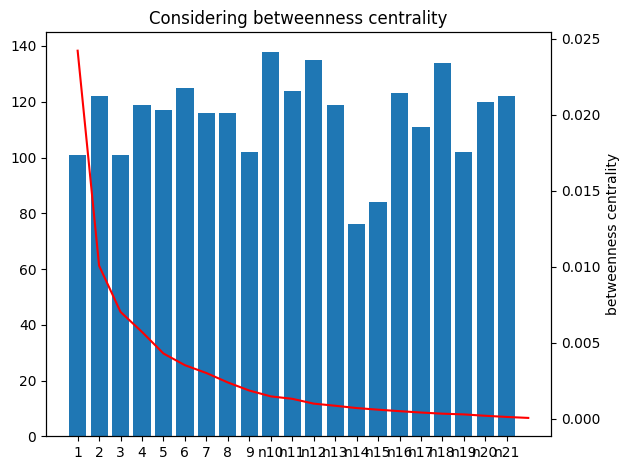

In [6]:
data_folder = Path(f'../../data/raw/random')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_200*.bz2"))
print(files)
x=[]
itr_count=[]
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    l=analyse.compute_param(df_d,0.05)
    num=l['tran_per'][-1]
    itr_count.append(num)

#plotting above as bar plot 
# sorting in ascending order

# uncomment below when need to plt in ascending order

# itr_count_arr=np.array(itr_count)
# ind=itr_count_arr.argsort()
# itr_count.sort()
# x=np.array(x)
# x=x[ind]

# SORT IN BETWEENNESS CENTRALITY DESCENDING ORDER

x_arr=np.array(x)
ind=x_arr.argsort()
x.sort()
itr_count=np.array(itr_count)
itr_count=itr_count[ind]

plt.bar(x,itr_count)
plt.twinx()


plt.plot(val,'r')
plt.title('Considering betweenness centrality')
plt.ylabel('betweenness centrality')
plt.xlabel('node set removed')
plt.tight_layout()
# print(f)

print(x)


#### Storing transition count wrt node pairs

In [7]:
x

array(['n22', 'n13', 'n10', 'n19', 'n17', 'n16', 'n15', 'n21', 'n12',
       'n11', 'n18', 'n20', '1', '5', '9', '8', 'n14', '4', '3', '7', '6',
       '2'], dtype='<U3')

In [7]:
itr_count

keys=list(x)
values=itr_count
trans_count_dict=dict(zip(keys,values))
print(trans_count_dict)





{'1': 101, '2': 122, '3': 101, '4': 119, '5': 117, '6': 125, '7': 116, '8': 116, '9': 102, 'n10': 138, 'n11': 124, 'n12': 135, 'n13': 119, 'n14': 76, 'n15': 84, 'n16': 123, 'n17': 111, 'n18': 134, 'n19': 102, 'n20': 120, 'n21': 122}


## NOTE: 
1. Find nc for n14(213,0) and n15(309,96) aand move the data to random nodes



For node 122, the brain region is PVH (Hypothalamus)  
For node 335, the brain region is ARH (Hth)  
For node 51, the brain region is CA3 (Hipocampus)  
For node 264, the brain region is DG (HP)  
For node 114, the brain region is RH (Thalamus)  
For node 327, the brain region is CM (thalamus)  
For node 132, the brain region is SUM (Hth)  
For node 345, the brain region is MPN (Thalamus)  
For node 309, the brain region is MGv (Thalamus) 
For node 96, the brain region is MGd (Thalamus)  
For node 334, the brain region is PVH (Hth)  
For node 121, the brain region is LH (Habenulla)  
For node 283, the brain region is LSc (HP)  
For node 70, the brain region is OT (basal ganglia ?)  
For node 158, the brain region is SNc (basal ganglia)  
For node 371, the brain region is PPN (brain stem)  
For node 73, the brain region is LSv (HP)  
For node 286, the brain region is SF (HP)  
For node 303, the brain region is VPMpc (Thalamus)  
For node 90, the brain region is VPM (Thalamus)  


# Finding connector hubs

The nodes with high degree centrality, high betweenness,  high eigen value, high nodal efficiency


In [12]:
import networkx as nx
import numpy as np
import community  # You may need to install 'python-louvain' package using 'pip install python-louvain'

def participation_coefficient(G):
    partition = community.best_partition(G)  # Detect communities
    node_community = {node: partition[node] for node in G.nodes()}
    
    participation_coeffs = {}
    
    for node in G.nodes():
        total_degree = G.degree(node)
        if total_degree == 0:
            participation_coeffs[node] = 0  # Isolated nodes have zero participation
            continue

        # Compute the fraction of edges in different communities
        community_edges = {}
        for neighbor in G.neighbors(node):
            comm = node_community[neighbor]
            community_edges[comm] = community_edges.get(comm, 0) + 1

        # Calculate participation coefficient
        coeff = 1 - sum((degree / total_degree) ** 2 for degree in community_edges.values())
        participation_coeffs[node] = coeff
    
    return participation_coeffs

# Example Usage



In [17]:
G = nx.from_numpy_array(net_meas.WHOLE_BRAIN_CONN)
# Generate a random graph
pc = participation_coefficient(G)
type(pc)
sorted_dict = dict(sorted(pc.items(), key=lambda item: item[1] ,reverse=True))
sorted_dict



{215: 0.8239288504296616,
 218: 0.8196909927679159,
 234: 0.8192387543252595,
 21: 0.8186851211072664,
 2: 0.8186407066882999,
 5: 0.8144312952005259,
 63: 0.812128418549346,
 76: 0.8095238095238095,
 147: 0.8090888839385164,
 4: 0.8079999999999999,
 111: 0.8077777777777778,
 276: 0.8073721759809751,
 113: 0.8052167612607173,
 324: 0.8049999999999999,
 217: 0.8040888888888889,
 360: 0.8032969480953441,
 326: 0.8028015940103852,
 289: 0.7981859410430839,
 221: 0.7943119793162884,
 350: 0.79388427734375,
 238: 0.7921048620637099,
 95: 0.791913214990138,
 308: 0.791913214990138,
 137: 0.79095458984375,
 237: 0.7881836050410451,
 8: 0.7879919563343867,
 374: 0.7861224489795918,
 161: 0.7857142857142857,
 25: 0.7857033988721231,
 24: 0.784483755347439,
 329: 0.7839506172839505,
 53: 0.7838565777291473,
 36: 0.7833486335710755,
 266: 0.7816682097466543,
 249: 0.7815126050420168,
 301: 0.7777777777777778,
 366: 0.7775677378701953,
 92: 0.7766272189349113,
 167: 0.7755102040816326,
 380: 0.775

In [4]:
G = nx.from_numpy_array(net_meas.WHOLE_BRAIN_CONN)

bet_cent = nx.betweenness_centrality(G)
top_betweenness_centrality= dict(sorted(bet_cent.items(), key=lambda x: x[1], reverse=True))


degree_centrality = nx.degree_centrality(G)
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))

deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(deg_cent_sorted)

bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(bet_cent_sorted)

common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted))

common_node

[1, 214, 2, 215, 137, 350, 36, 249, 53, 266, 140, 353, 150, 363, 149, 362, 151, 364, 24, 237]
[214, 1, 137, 350, 2, 215, 36, 249, 266, 53, 95, 308, 171, 384, 164, 377, 167, 380, 326, 113]


[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

## Finding Nodal Efficiency


In [14]:
import networkx as nx

def calculate_nodal_efficiency(G):
    """
    Calculate the nodal efficiency for each node in the network.
    
    Parameters:
        G (networkx.Graph): The graph representing the network.
    
    Returns:
        dict: A dictionary with nodes as keys and their efficiency as values.
    """
    efficiency = {}
    for node in G.nodes:
        # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
        sp_lengths = nx.shortest_path_length(G, source=node)
        sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)
        
        # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
        # where N is the number of nodes and d(v, u) is the shortest path length between v and u
        efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)
    
    return efficiency

In [15]:
ne=calculate_nodal_efficiency(G)
type(ne)

dict

## Finding Hubs i.e common nodes in top 20 nodes which have high degree, high betweenness centrality and nodal efficiency

In [23]:
sorted_dict = dict(sorted(ne.items(), key=lambda item: item[1],reverse=True))
sorted_dict
top_nodal_efficiency = list(sorted_dict.keys())[0:20]
top_nodal_efficiency
common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted) & set(top_nodal_efficiency))
common_node


[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

In [ ]:
[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

## Getting order data for connector hubs. 
Data is in 'raw/check_connector' folder

node pairs:  

Done  
1. 214,1.
2. 215,2.
3. 249,36
4. 137,350
5. 53,266




# Finding eigen vector centrality

In [3]:
G = nx.from_numpy_array(net_meas.WHOLE_BRAIN_CONN)
eigen_centrality = nx.eigenvector_centrality(G)

top_ev_centrality = dict(sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True))

deg_ev_sorted =list(top_ev_centrality.keys())[0:20]
print(f'Top degree centrality nodes:{deg_ev_sorted}')

# print("Eigenvector Centrality (NetworkX):")
# for node, centrality in top_ev_centrality.items():
#     print(f"{node}: {centrality:.4f}")

Top degree centrality nodes:[1, 214, 215, 2, 137, 350, 364, 151, 140, 353, 150, 363, 149, 362, 36, 249, 167, 380, 24, 237]


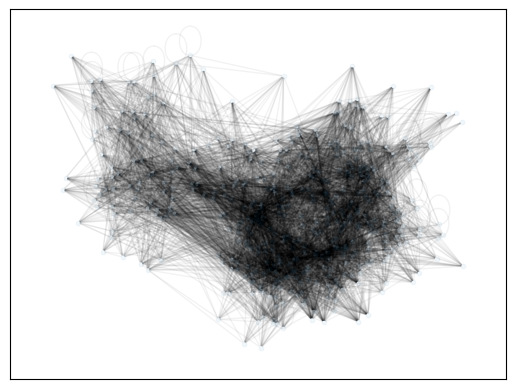

In [10]:
nx.draw_networkx(G,node_size=10,with_labels=False,alpha=0.05,arrows=True,arrowsize=1)





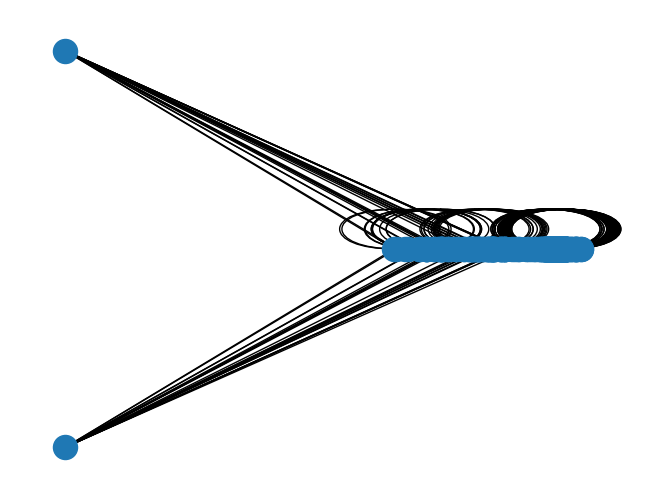

In [12]:
nx.draw_s

